# Image Classification with CNN — Flower Dataset

**Dataset:** Flower Classification (Daisy · Dandelion · Rose · Sunflower · Tulip)

---

## Part A: CNN from Scratch

### Imports

In [ ]:
# File and directory handling
import os
import shutil
import time
import random

# Data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from collections import Counter

# Image utilities
from PIL import Image

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Deep learning (Keras / TensorFlow)
from tensorflow.keras.models import Sequential, load_model, clone_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization,
    GlobalAveragePooling2D, Input
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

### Mount Google Drive & Set Paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Adjust this path to where you extracted the dataset
RAW_DIR   = '/content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Flower_Classification/Train'
SPLIT_DIR = '/content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Flower_Classification/Test'
TRAIN_DIR = os.path.join(SPLIT_DIR, 'train')
VAL_DIR   = os.path.join(SPLIT_DIR, 'val')
TEST_DIR  = os.path.join(SPLIT_DIR, 'test')

CLASS_NAMES = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
IMG_SIZE    = (150, 150)
BATCH_SIZE  = 32
SEED        = 42
VALID_EXTS  = ('.jpg', '.jpeg', '.png')

---
## 2.5.1 Data Understanding, Analysis, Visualisation and Cleaning

### Dataset Description
The **Flower Classification** dataset contains labelled colour photographs of five common flower species: *daisy, dandelion, rose, sunflower* and *tulip*. It is a standard multi-class image-classification benchmark with ~4 277 images total across unequally-sized classes.

In [ ]:
# Count images per class
class_counts = {}
for cls in CLASS_NAMES:
    cls_path = os.path.join(RAW_DIR, cls)
    class_counts[cls] = len([f for f in os.listdir(cls_path)
                              if f.lower().endswith(VALID_EXTS)])

df_counts = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Number of Images'])
total_images = df_counts['Number of Images'].sum()
print(f"Total images in dataset: {total_images}")
print(df_counts)

Total images in dataset: 4277
       Class  Number of Images
0      daisy               756
1  dandelion              1044
2       rose               776
3  sunflower               725
4      tulip               976


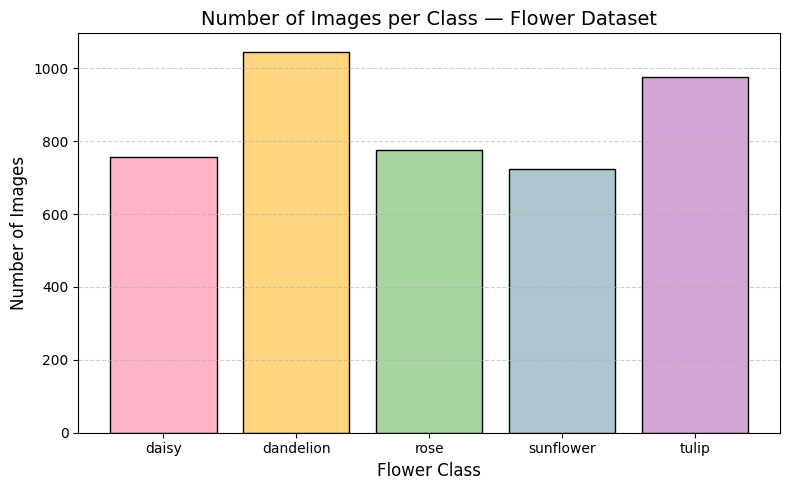

In [ ]:
# Class distribution bar chart
colors = ['#FFB3C6', '#FFD580', '#A8D5A2', '#AEC6CF', '#D4A5D5']

plt.figure(figsize=(8, 5))
plt.bar(df_counts['Class'], df_counts['Number of Images'], color=colors, edgecolor='black')
plt.title('Number of Images per Class — Flower Dataset', fontsize=14)
plt.xlabel('Flower Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

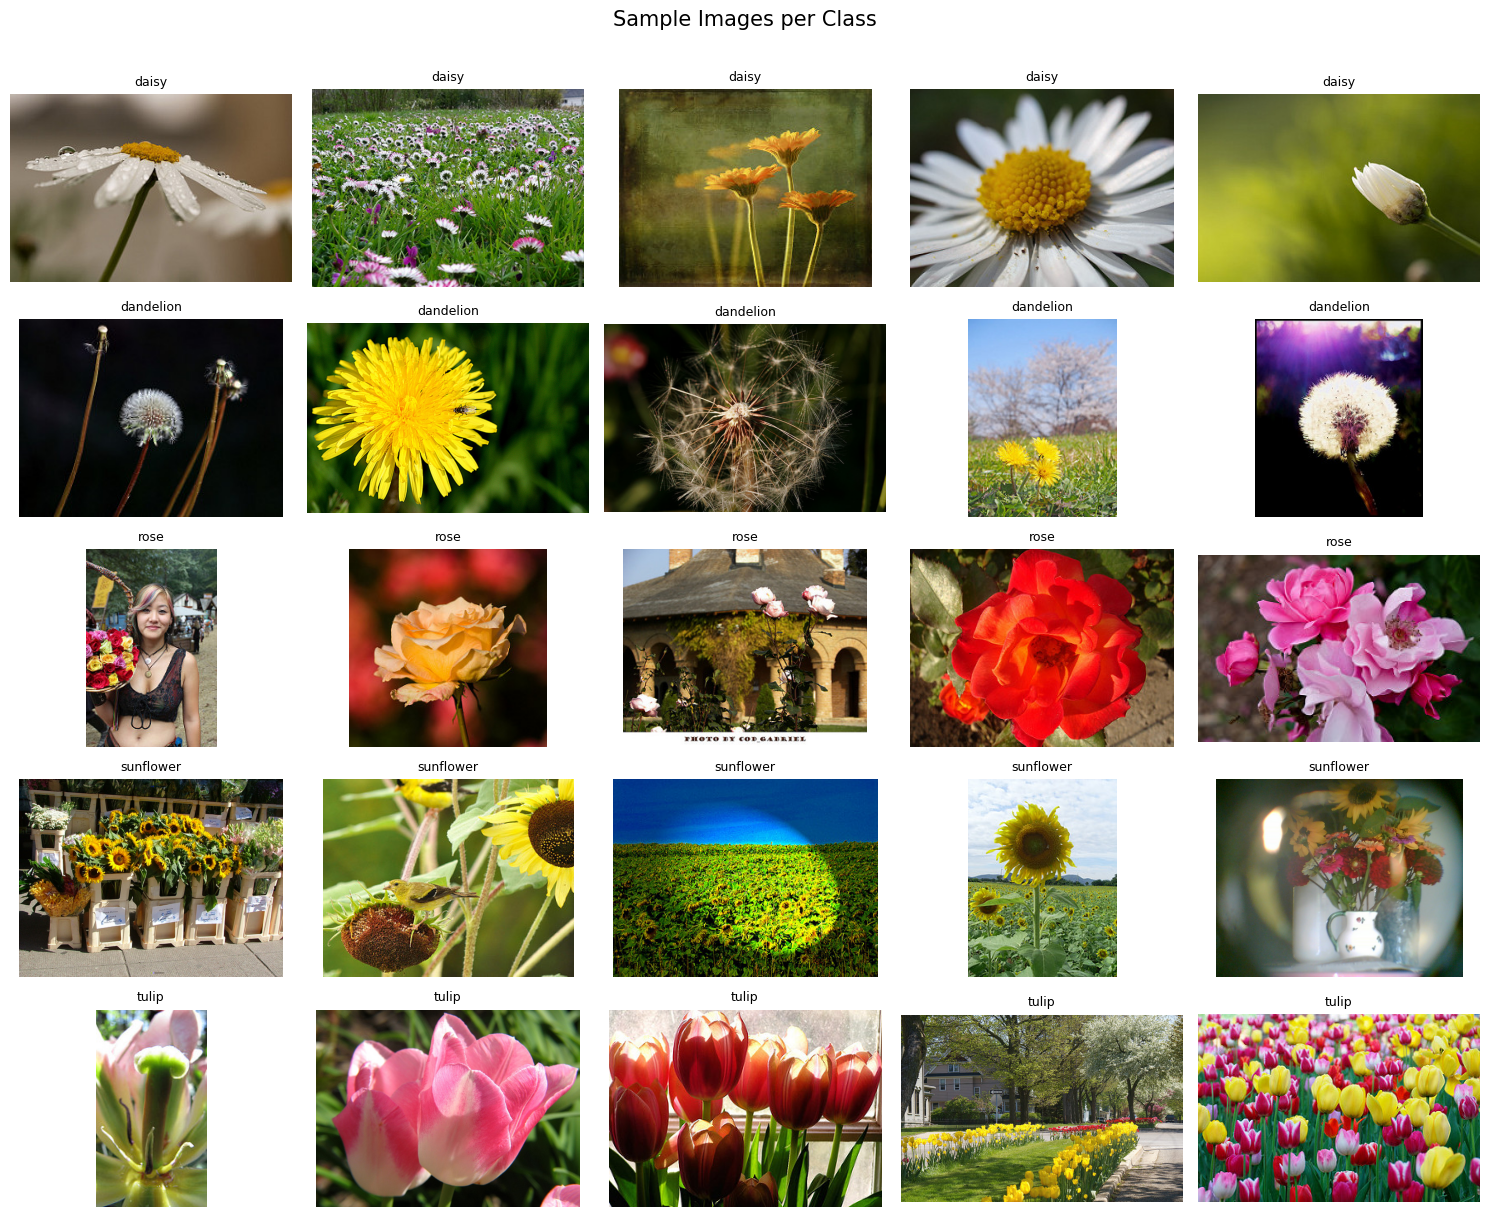

In [ ]:
# Display 5 random sample images per class
NUM_SAMPLES = 5
plt.figure(figsize=(15, 12))
for i, cls in enumerate(CLASS_NAMES):
    cls_folder = os.path.join(RAW_DIR, cls)
    imgs = [f for f in os.listdir(cls_folder) if f.lower().endswith(VALID_EXTS)]
    selected = random.sample(imgs, NUM_SAMPLES)
    for j, img_name in enumerate(selected):
        img = mpimg.imread(os.path.join(cls_folder, img_name))
        plt.subplot(len(CLASS_NAMES), NUM_SAMPLES, i * NUM_SAMPLES + j + 1)
        plt.imshow(img); plt.title(cls, fontsize=9); plt.axis('off')
plt.suptitle('Sample Images per Class', fontsize=15, y=1.01)
plt.tight_layout(); plt.show()

### Train / Validation / Test Split (70 / 15 / 15)
A stratified 70/15/15 split is applied to preserve class proportions across all subsets.
- **70% training** — sufficient data for learning features.
- **15% validation** — used for early stopping and hyper-parameter tuning.
- **15% test** — held out completely for final unbiased evaluation.

In [ ]:
# Build train / val / test split
for split in ['train', 'val', 'test']:
    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

for cls in CLASS_NAMES:
    cls_path = os.path.join(RAW_DIR, cls)
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(VALID_EXTS)]
    train_f, temp_f = train_test_split(files, test_size=0.30, random_state=SEED)
    val_f, test_f   = train_test_split(temp_f, test_size=0.50, random_state=SEED)
    for fname in train_f:
        shutil.copy(os.path.join(cls_path, fname), os.path.join(TRAIN_DIR, cls, fname))
    for fname in val_f:
        shutil.copy(os.path.join(cls_path, fname), os.path.join(VAL_DIR, cls, fname))
    for fname in test_f:
        shutil.copy(os.path.join(cls_path, fname), os.path.join(TEST_DIR, cls, fname))

print("Split complete!")

Split complete!


In [ ]:
# Count split totals
def count_split(folder):
    totals, total_count = {}, 0
    for cls in CLASS_NAMES:
        p = os.path.join(folder, cls)
        n = len([f for f in os.listdir(p) if f.lower().endswith(VALID_EXTS)])
        totals[cls] = n; total_count += n
    return total_count, totals

tr_total, tr_cls = count_split(TRAIN_DIR)
va_total, va_cls = count_split(VAL_DIR)
te_total, te_cls = count_split(TEST_DIR)
print(f"Train : {tr_total}  {tr_cls}")
print(f"Val   : {va_total}  {va_cls}")
print(f"Test  : {te_total}  {te_cls}")

Train : 2992  {'daisy': 529, 'dandelion': 730, 'rose': 543, 'sunflower': 507, 'tulip': 683}
Val   : 641  {'daisy': 113, 'dandelion': 157, 'rose': 116, 'sunflower': 109, 'tulip': 146}
Test  : 644  {'daisy': 114, 'dandelion': 157, 'rose': 117, 'sunflower': 109, 'tulip': 147}


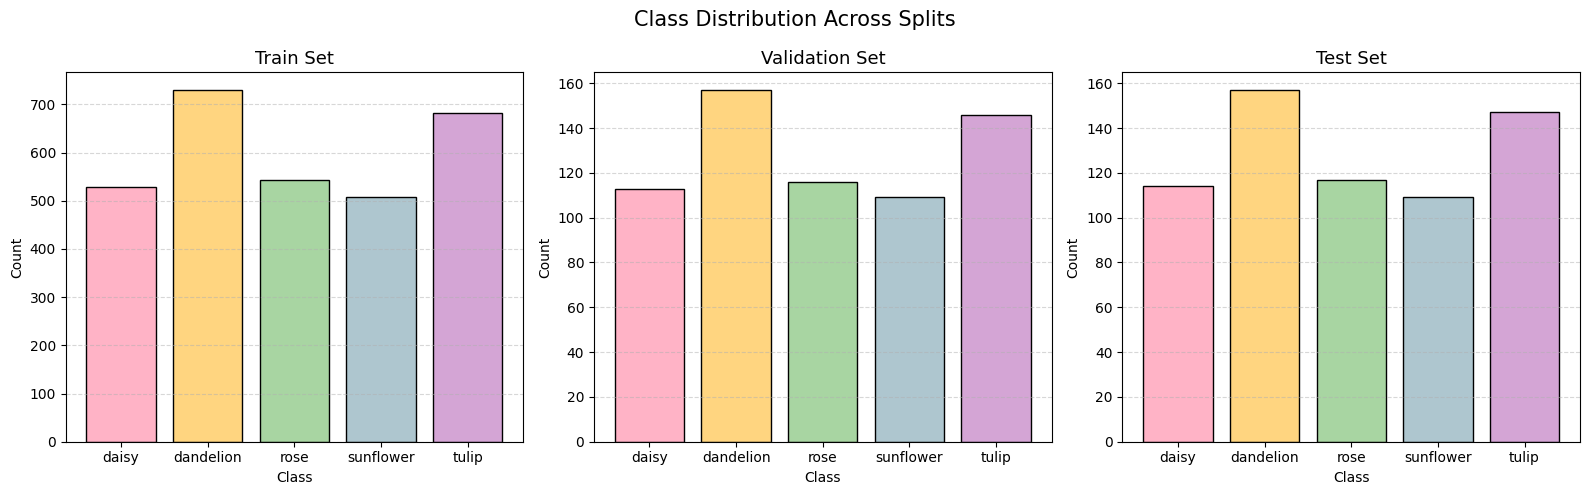

In [ ]:
# Visualise split distributions
splits      = ['Train', 'Validation', 'Test']
split_dicts = [tr_cls, va_cls, te_cls]
fig, axes   = plt.subplots(1, 3, figsize=(16, 5))
for ax, name, d in zip(axes, splits, split_dicts):
    ax.bar(d.keys(), d.values(), color=colors, edgecolor='black')
    ax.set_title(f'{name} Set', fontsize=13)
    ax.set_xlabel('Class'); ax.set_ylabel('Count')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.suptitle('Class Distribution Across Splits', fontsize=15)
plt.tight_layout(); plt.show()

### Data Cleaning — Invalid / Corrupt Images

In [ ]:
def check_and_remove_corrupt(folder):
    removed = 0
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if not os.path.isdir(cls_path): continue
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            try:
                img = Image.open(fpath); img.verify()
            except Exception as e:
                print(f"Corrupt — removing: {fpath} | {e}")
                os.remove(fpath); removed += 1
    print(f"  Removed {removed} corrupt images from {folder}")

for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    check_and_remove_corrupt(split_dir)
print("Data cleaning complete.")

  Removed 0 corrupt images from /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Flower_Classification/Test/train
  Removed 0 corrupt images from /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Flower_Classification/Test/val
  Removed 0 corrupt images from /content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Flower_Classification/Test/test
Data cleaning complete.


### Preprocessing and Data Augmentation

**Normalisation:** pixel values rescaled to [0, 1].

**Training augmentation:** horizontal flip, rotation ±20°, width/height shift ±15%, zoom ±15%, shear 15°. Augmentation artificially expands the training set and reduces over-fitting.

**Validation / test generators** use only rescaling — no augmentation — to ensure unbiased evaluation.

In [ ]:
# Training augmentation generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    shear_range=0.15,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED, shuffle=True)
val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED, shuffle=False)
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED, shuffle=False)

print("Class indices:", train_generator.class_indices)

Found 2992 images belonging to 5 classes.
Found 641 images belonging to 5 classes.
Found 644 images belonging to 5 classes.
Class indices: {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}


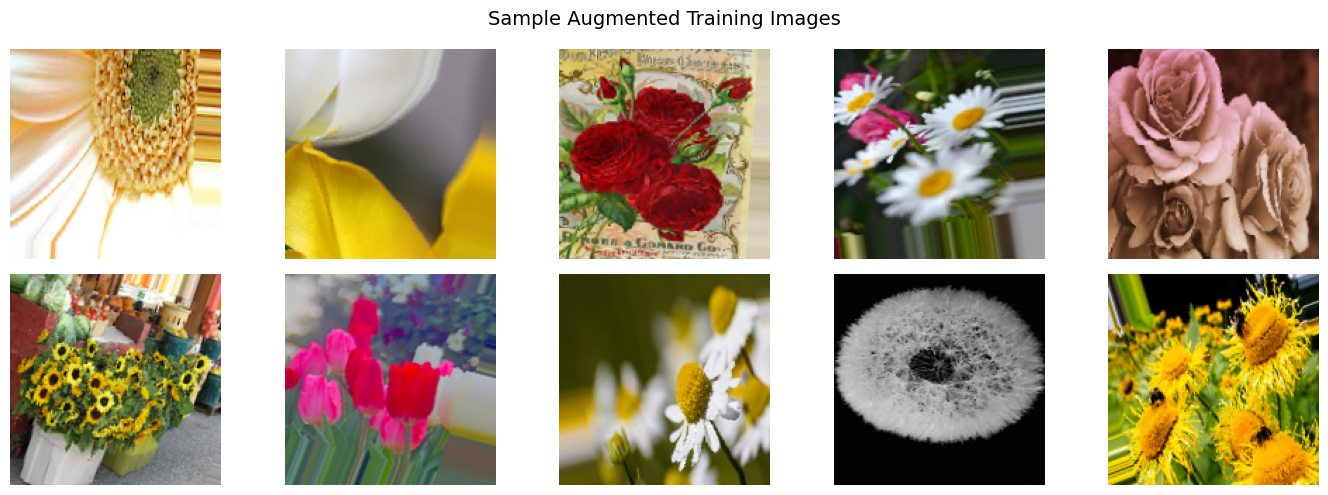

In [ ]:
# Visualise augmented training images
aug_batch, _ = next(iter(train_generator))
plt.figure(figsize=(14, 5))
plt.suptitle('Sample Augmented Training Images', fontsize=14)
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(aug_batch[i]); plt.axis('off')
plt.tight_layout(); plt.show()

---
## 2.5.2 Baseline CNN Model

### Architecture
3 Conv–Pool blocks + 3 fully-connected layers + softmax output.

| Layer | Filters/Units | Kernel | Activation |
|---|---|---|---|
| Conv2D #1 | 32 | 3×3 | ReLU |
| MaxPool #1 | — | 2×2 | — |
| Conv2D #2 | 64 | 3×3 | ReLU |
| MaxPool #2 | — | 2×2 | — |
| Conv2D #3 | 128 | 3×3 | ReLU |
| MaxPool #3 | — | 2×2 | — |
| Dense #1 | 256 | — | ReLU |
| Dropout 0.5 | — | — | — |
| Dense #2 | 128 | — | ReLU |
| Dropout 0.3 | — | — | — |
| Dense #3 (output) | 5 | — | Softmax |

In [ ]:
def build_baseline():
    model = Sequential([
        Input(shape=(150, 150, 3)),
        # Block 1
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        # Block 2
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        # Block 3
        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(256, activation='relu'), Dropout(0.5),
        Dense(128, activation='relu'), Dropout(0.3),
        Dense(5, activation='softmax')
    ])
    return model

baseline_model = build_baseline()
baseline_model.compile(optimizer=Adam(learning_rate=0.001),
                       loss='categorical_crossentropy', metrics=['accuracy'])
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,743,877 (40.98 MB)

 Trainable params: 10,743,877 (40.98 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train baseline model
checkpoint_baseline = '/content/drive/MyDrive/Flower_Classification/models/baseline_model.keras'
os.makedirs(os.path.dirname(checkpoint_baseline), exist_ok=True)

callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=checkpoint_baseline, monitor='val_loss', save_best_only=True, verbose=1)
]

start = time.time()
history_baseline = baseline_model.fit(
    train_generator, epochs=30,
    validation_data=val_generator,
    callbacks=callbacks_baseline, verbose=1)
elapsed_baseline = time.time() - start
print(f"\nBaseline training time: {elapsed_baseline/60:.1f} minutes")

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.2556 - loss: 1.6670
Epoch 1: val_loss improved from None to 1.22734, saving model to /content/drive/MyDrive/Flower_Classification/models/baseline_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Flower_Classification/models/baseline_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 54s 476ms/step - accuracy: 0.2888 - loss: 1.5519 - val_accuracy: 0.4914 - val_loss: 1.2273
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.4473 - loss: 1.2877
Epoch 2: val_loss improved from 1.22734 to 1.04936, saving model to /content/drive/MyDrive/Flower_Classification/models/baseline_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Flower_Classification/models/baseline_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 68s 400ms/step - accuracy: 0.4609 - loss: 1.2656 - val_accuracy: 0.6006 - val_loss: 1.0494
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.5127 - loss: 1.1779
Epoch 3: va

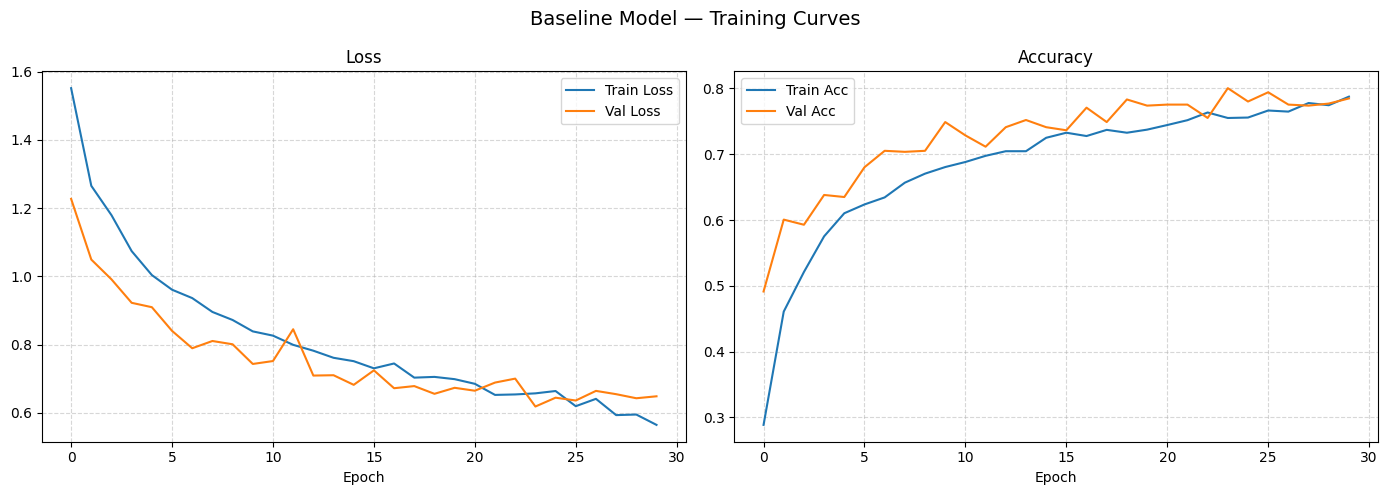

In [ ]:
# Helper: plot loss and accuracy curves
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14)
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[0].grid(linestyle='--', alpha=0.5)
    axes[1].plot(history.history['accuracy'], label='Train Acc')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
    axes[1].grid(linestyle='--', alpha=0.5)
    plt.tight_layout(); plt.show()

plot_history(history_baseline, 'Baseline Model — Training Curves')

In [ ]:
# Evaluate baseline model
baseline_model = load_model(checkpoint_baseline)
test_generator.reset()
loss_b, acc_b = baseline_model.evaluate(test_generator, verbose=1)
print(f"\nBaseline Test Accuracy : {acc_b:.2%}")
print(f"Baseline Test Loss     : {loss_b:.4f}")

test_generator.reset()
y_pred_b    = np.argmax(baseline_model.predict(test_generator, verbose=0), axis=1)
y_true      = test_generator.classes
class_names = list(test_generator.class_indices.keys())
print("\nClassification Report — Baseline Model:")
print(classification_report(y_true, y_pred_b, target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 222ms/step - accuracy: 0.7562 - loss: 0.6821

Baseline Test Accuracy : 75.62%
Baseline Test Loss     : 0.6821

Classification Report — Baseline Model:
              precision    recall  f1-score   support

       daisy       0.77      0.77      0.77       114
   dandelion       0.80      0.80      0.80       157
        rose       0.73      0.53      0.61       117
   sunflower       0.82      0.88      0.85       109
       tulip       0.68      0.78      0.73       147

    accuracy                           0.76       644
   macro avg       0.76      0.75      0.75       644
weighted avg       0.76      0.76      0.75       644



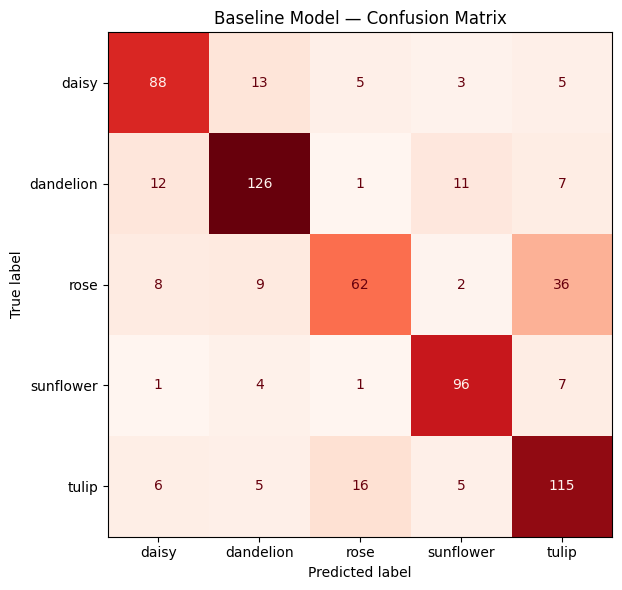

In [ ]:
# Confusion matrix — baseline
cm_b = confusion_matrix(y_true, y_pred_b)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_b, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap=plt.cm.Reds, ax=ax, colorbar=False)
plt.title('Baseline Model — Confusion Matrix'); plt.tight_layout(); plt.show()

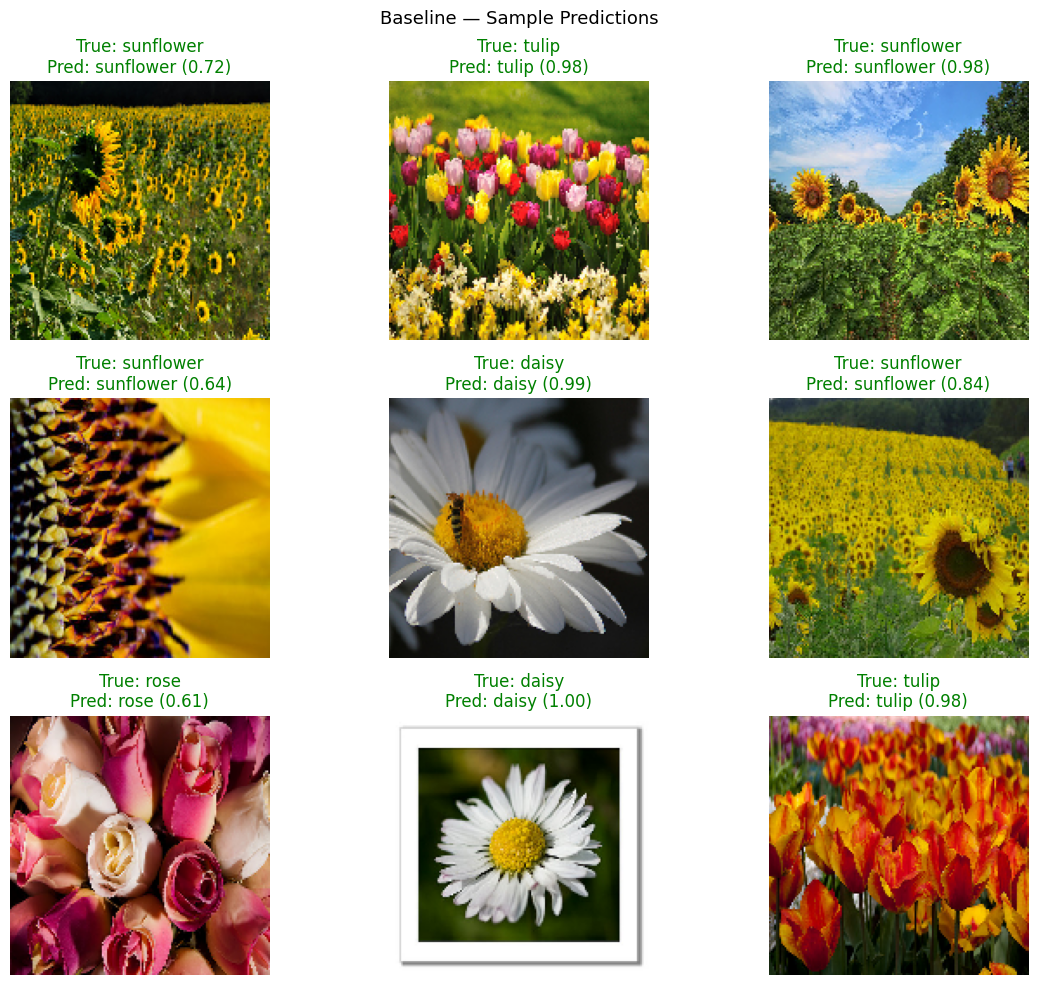

In [ ]:
# Inference on 9 random test images
idx_to_class = {v: k for k, v in test_generator.class_indices.items()}
sample_data  = []
for cls in os.listdir(TEST_DIR):
    cls_folder = os.path.join(TEST_DIR, cls)
    for f in os.listdir(cls_folder):
        if f.lower().endswith(VALID_EXTS):
            sample_data.append((os.path.join(cls_folder, f), cls))

sample_paths = random.sample(sample_data, 9)
plt.figure(figsize=(12, 10))
for i, (img_path, true_label) in enumerate(sample_paths):
    img  = load_img(img_path, target_size=IMG_SIZE)
    x    = img_to_array(img) / 255.0
    x    = np.expand_dims(x, axis=0)
    prob = baseline_model.predict(x, verbose=0)[0]
    pred = idx_to_class[np.argmax(prob)]
    ax   = plt.subplot(3, 3, i + 1); plt.imshow(img); plt.axis('off')
    color = 'green' if pred == true_label else 'red'
    ax.set_title(f"True: {true_label}\nPred: {pred} ({prob.max():.2f})", color=color)
plt.suptitle('Baseline — Sample Predictions', fontsize=13)
plt.tight_layout(); plt.show()

---
## 2.5.3 Deeper Architecture with Regularisation

The deeper model **doubles the convolutional depth** (6 Conv–Pool blocks vs 3) and introduces:
- **Batch Normalisation** after every Conv layer to stabilise activations
- **Dropout** (0.25) after each pool block, and (0.5 / 0.3) in the dense head
- Higher filter progression: 64 → 64 → 128 → 128 → 256 → 256

In [ ]:
def build_deeper():
    model = Sequential([
        Input(shape=(150, 150, 3)),
        # Block 1
        Conv2D(64,  (3,3), activation='relu', padding='same'), BatchNormalization(),
        Conv2D(64,  (3,3), activation='relu', padding='same'), BatchNormalization(),
        MaxPooling2D(2, 2), Dropout(0.25),
        # Block 2
        Conv2D(128, (3,3), activation='relu', padding='same'), BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'), BatchNormalization(),
        MaxPooling2D(2, 2), Dropout(0.25),
        # Block 3
        Conv2D(256, (3,3), activation='relu', padding='same'), BatchNormalization(),
        Conv2D(256, (3,3), activation='relu', padding='same'), BatchNormalization(),
        MaxPooling2D(2, 2), Dropout(0.25),
        Flatten(),
        Dense(512, activation='relu'), Dropout(0.5),
        Dense(256, activation='relu'), Dropout(0.3),
        Dense(5,   activation='softmax')
    ])
    return model

deeper_model = build_deeper()
deeper_model.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy', metrics=['accuracy'])
deeper_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 150, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 75, 75, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 37, 37, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 37, 37, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │    42,467,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,32

 Total params: 43,749,445 (166.89 MB)

 Trainable params: 43,747,653 (166.88 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
# Train deeper model
checkpoint_deeper = '/content/drive/MyDrive/Flower_Classification/models/deeper_model.keras'
callbacks_deeper = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=checkpoint_deeper, monitor='val_loss', save_best_only=True, verbose=1)
]
start_d = time.time()
history_deeper = deeper_model.fit(
    train_generator, epochs=30,
    validation_data=val_generator,
    callbacks=callbacks_deeper, verbose=1)
train_time_deeper = time.time() - start_d
print(f"\nDeeper model training time: {train_time_deeper/60:.1f} minutes")

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.2783 - loss: 33.5463
Epoch 1: val_loss improved from None to 5.83962, saving model to /content/drive/MyDrive/Flower_Classification/models/deeper_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Flower_Classification/models/deeper_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 99s 714ms/step - accuracy: 0.3058 - loss: 25.4329 - val_accuracy: 0.1810 - val_loss: 5.8396
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.3276 - loss: 11.3006
Epoch 2: val_loss improved from 5.83962 to 2.13250, saving model to /content/drive/MyDrive/Flower_Classification/models/deeper_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Flower_Classification/models/deeper_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 469ms/step - accuracy: 0.3386 - loss: 9.2328 - val_accuracy: 0.2402 - val_loss: 2.1325
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.3406 - loss: 4.6863
Epoch 3: val_los

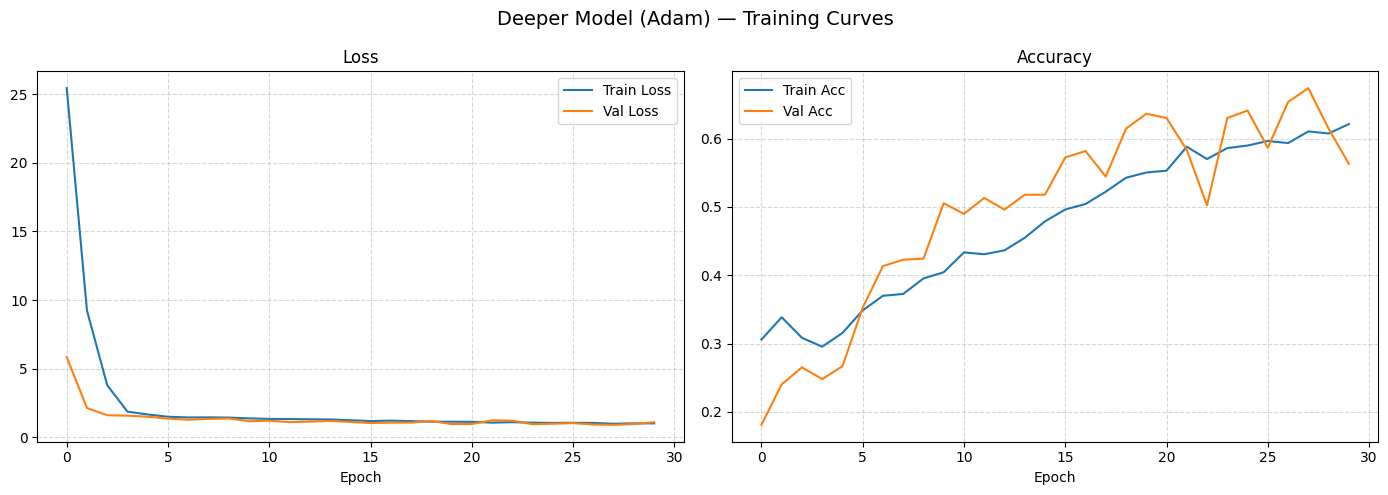

In [ ]:
plot_history(history_deeper, 'Deeper Model (Adam) — Training Curves')

In [ ]:
# Evaluate deeper model
deeper_model = load_model(checkpoint_deeper)
test_generator.reset()
loss_d, acc_d = deeper_model.evaluate(test_generator, verbose=1)
print(f"\nDeeper Test Accuracy : {acc_d:.2%}")
print(f"Deeper Test Loss     : {loss_d:.4f}")
test_generator.reset()
y_pred_d = np.argmax(deeper_model.predict(test_generator, verbose=0), axis=1)
print("\nClassification Report — Deeper Model:")
print(classification_report(y_true, y_pred_d, target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 227ms/step - accuracy: 0.6522 - loss: 0.9597

Deeper Test Accuracy : 65.22%
Deeper Test Loss     : 0.9597

Classification Report — Deeper Model:
              precision    recall  f1-score   support

       daisy       0.66      0.67      0.66       114
   dandelion       0.72      0.66      0.68       157
        rose       0.56      0.53      0.55       117
   sunflower       0.62      0.90      0.74       109
       tulip       0.69      0.55      0.61       147

    accuracy                           0.65       644
   macro avg       0.65      0.66      0.65       644
weighted avg       0.66      0.65      0.65       644



---
## 2.5.4 Experimentation and Comparative Analysis

### 1. Baseline vs Deeper Performance

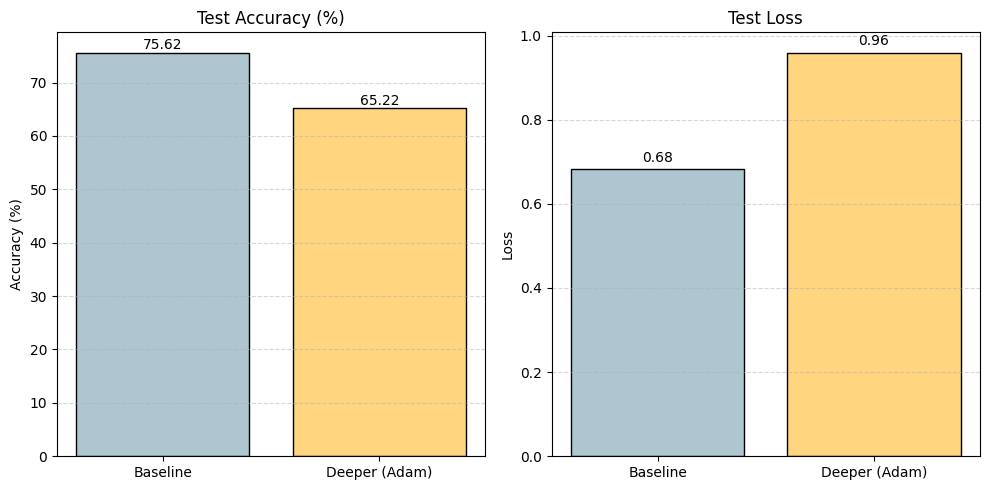

In [ ]:
bar_colors   = ['#AEC6CF', '#FFD580']
model_labels = ['Baseline', 'Deeper (Adam)']
fig, axes    = plt.subplots(1, 2, figsize=(10, 5))
for ax, vals, title, ylabel in zip(
        axes,
        [[acc_b*100, acc_d*100], [loss_b, loss_d]],
        ['Test Accuracy (%)', 'Test Loss'], ['Accuracy (%)', 'Loss']):
    bars = ax.bar(model_labels, vals, color=bar_colors, edgecolor='black')
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f"{b.get_height():.2f}", ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.show()

### 2. Computational Efficiency

In [ ]:
print("Training Time Comparison:")
print(f"  Baseline     : {elapsed_baseline/60:.1f} minutes")
print(f"  Deeper (Adam): {train_time_deeper/60:.1f} minutes")

Training Time Comparison:
  Baseline     : 18.4 minutes
  Deeper (Adam): 23.7 minutes


### 3. Optimizer Analysis — SGD vs Adam

In [ ]:
# Train deeper architecture with SGD
checkpoint_sgd = '/content/drive/MyDrive/Flower_Classification/models/deeper_sgd.keras'
sgd_model = build_deeper()
sgd_model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                  loss='categorical_crossentropy', metrics=['accuracy'])
callbacks_sgd = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=checkpoint_sgd, monitor='val_loss', save_best_only=True, verbose=1)
]
start_s = time.time()
history_sgd = sgd_model.fit(
    train_generator, epochs=30,
    validation_data=val_generator,
    callbacks=callbacks_sgd, verbose=1)
train_time_sgd = time.time() - start_s
print(f"\nSGD training time: {train_time_sgd/60:.1f} minutes")

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.2174 - loss: 19.5727
Epoch 1: val_loss improved from None to 1.59898, saving model to /content/drive/MyDrive/Flower_Classification/models/deeper_sgd.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Flower_Classification/models/deeper_sgd.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 64s 586ms/step - accuracy: 0.2246 - loss: 8.9101 - val_accuracy: 0.2449 - val_loss: 1.5990
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.2469 - loss: 1.6045
Epoch 2: val_loss improved from 1.59898 to 1.59826, saving model to /content/drive/MyDrive/Flower_Classification/models/deeper_sgd.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Flower_Classification/models/deeper_sgd.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 436ms/step - accuracy: 0.2433 - loss: 1.6069 - val_accuracy: 0.2449 - val_loss: 1.5983
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.2440 - loss: 1.6674
Epoch 3: val_loss improved

In [ ]:
sgd_model = load_model(checkpoint_sgd)
test_generator.reset()
loss_s, acc_s = sgd_model.evaluate(test_generator, verbose=1)
print(f"\nAdam  — Acc: {acc_d:.2%}  Loss: {loss_d:.4f}  Time: {train_time_deeper/60:.1f} min")
print(f"SGD   — Acc: {acc_s:.2%}  Loss: {loss_s:.4f}  Time: {train_time_sgd/60:.1f} min")

21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - accuracy: 0.2438 - loss: 1.5983

Adam  — Acc: 65.22%  Loss: 0.9597  Time: 23.7 min
SGD   — Acc: 24.38%  Loss: 1.5983  Time: 9.5 min


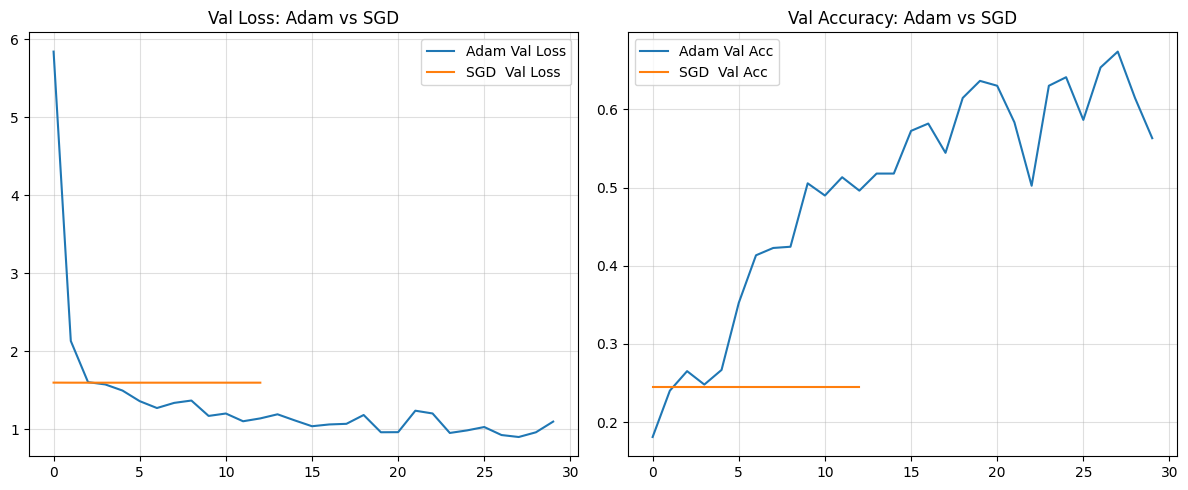

In [ ]:
# Overlay validation curves: Adam vs SGD
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_deeper.history['val_loss'], label='Adam Val Loss')
plt.plot(history_sgd.history['val_loss'],    label='SGD  Val Loss')
plt.title('Val Loss: Adam vs SGD'); plt.legend(); plt.grid(alpha=0.4)
plt.subplot(1, 2, 2)
plt.plot(history_deeper.history['val_accuracy'], label='Adam Val Acc')
plt.plot(history_sgd.history['val_accuracy'],    label='SGD  Val Acc')
plt.title('Val Accuracy: Adam vs SGD'); plt.legend(); plt.grid(alpha=0.4)
plt.tight_layout(); plt.show()

### 4. Ablation Study — Remove Batch Normalisation

In [ ]:
def build_deeper_no_bn():
    model = Sequential([
        Input(shape=(150, 150, 3)),
        Conv2D(64,  (3,3), activation='relu', padding='same'),
        Conv2D(64,  (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2), Dropout(0.25),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2), Dropout(0.25),
        Conv2D(256, (3,3), activation='relu', padding='same'),
        Conv2D(256, (3,3), activation='relu', padding='same'),
        MaxPooling2D(2,2), Dropout(0.25),
        Flatten(),
        Dense(512, activation='relu'), Dropout(0.5),
        Dense(256, activation='relu'), Dropout(0.3),
        Dense(5,   activation='softmax')
    ])
    return model

checkpoint_abl = '/content/drive/MyDrive/Flower_Classification/models/ablation_no_bn.keras'
ablation_model = build_deeper_no_bn()
ablation_model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
history_abl = ablation_model.fit(
    train_generator, epochs=30, validation_data=val_generator,
    callbacks=[EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
               ModelCheckpoint(checkpoint_abl, monitor='val_loss', save_best_only=True)],
    verbose=1)
ablation_model = load_model(checkpoint_abl)
test_generator.reset()
_, acc_abl = ablation_model.evaluate(test_generator, verbose=1)
print(f"\nAblation (No BN) Accuracy : {acc_abl:.2%}")
print(f"With BN Accuracy          : {acc_d:.2%}")

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 58s 516ms/step - accuracy: 0.2413 - loss: 1.6261 - val_accuracy: 0.2449 - val_loss: 1.5985
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 461ms/step - accuracy: 0.2436 - loss: 1.5997 - val_accuracy: 0.2449 - val_loss: 1.5983
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 51s 544ms/step - accuracy: 0.2416 - loss: 1.5996 - val_accuracy: 0.2449 - val_loss: 1.5983
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 43s 456ms/step - accuracy: 0.2420 - loss: 1.5991 - val_accuracy: 0.2449 - val_loss: 1.5982
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 52s 547ms/step - accuracy: 0.2423 - loss: 1.5992 - val_accuracy: 0.2449 - val_loss: 1.5984
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 37s 388ms/step - accuracy: 0.2440 - loss: 1.5996 - val_accuracy: 0.2449 - val_loss: 1.5982
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 38s 400ms/step - accuracy: 0.2433 - loss: 1.5991 - val_accuracy: 0.2449 - val_loss: 1.5984
Epoch 8/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 36s 387ms/step - accuracy: 0.2433 - loss: 1.6003 - val_accu

### 5. Challenges and Observations

- **Overfitting**: The baseline model shows training accuracy rising while validation accuracy plateaus — a textbook sign of overfitting on a small dataset. Dropout and augmentation partially mitigate this.
- **Batch Normalisation**: Removing BN (ablation) leads to slower convergence and lower final accuracy, confirming its importance.
- **SGD vs Adam**: Adam converges faster but SGD + momentum tends to generalise comparably or better given sufficient epochs.
- **Hardware**: Training was performed on Google Colab with T4/L4 GPU. Without GPU acceleration, deeper models would be impractical.

---
# Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)

We use **VGG16** pre-trained on ImageNet, which expects 224×224 inputs. Separate generators are created at this resolution.

In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Definitions from a previous cell (Cyx68AGgj_Nf) to ensure variables are defined
# Corrected SPLIT_DIR to point to the actual split data location
SPLIT_DIR = '/content/drive/MyDrive/2408180_IshaBhatta_Portfolio/Flower_Classification/Test'
TRAIN_DIR = os.path.join(SPLIT_DIR, 'train')
VAL_DIR   = os.path.join(SPLIT_DIR, 'val')
TEST_DIR  = os.path.join(SPLIT_DIR, 'test')
SEED      = 42

IMG_SIZE_TL = (224, 224)

train_gen_tl = ImageDataGenerator(
    rescale=1./255, horizontal_flip=True,
    rotation_range=20, width_shift_range=0.15,
    height_shift_range=0.15, zoom_range=0.15,
    shear_range=0.15, fill_mode='nearest'
).flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE_TL,
    batch_size=32, class_mode='categorical', seed=SEED, shuffle=True)

val_gen_tl = ImageDataGenerator(rescale=1./255).flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE_TL, batch_size=32,
    class_mode='categorical', seed=SEED, shuffle=False)

test_gen_tl = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE_TL, batch_size=32,
    class_mode='categorical', seed=SEED, shuffle=False)

Found 2992 images belonging to 5 classes.
Found 641 images belonging to 5 classes.
Found 644 images belonging to 5 classes.


### 2.6.1 Load and Adapt VGG16

The original 1000-class softmax head is removed. A new classification head suited to 5 flower classes is added. The convolutional base is initially frozen (feature extraction phase).

In [ ]:
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_vgg.trainable = False   # freeze base initially

transfer_model = Sequential([
    base_vgg,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')   # 5 flower classes
])
transfer_model.compile(optimizer=Adam(learning_rate=0.0001),
                       loss='categorical_crossentropy', metrics=['accuracy'])
transfer_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,109,957 (57.64 MB)

 Trainable params: 395,269 (1.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### 2.6.2 Feature Extraction Phase
Only the newly added dense layers are trained; the VGG16 base remains frozen.

In [ ]:
checkpoint_tl = '/content/drive/MyDrive/Flower_Classification/models/transfer_feat_extract.keras'
callbacks_tl = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=checkpoint_tl, monitor='val_loss', save_best_only=True, verbose=1)
]
start_tl = time.time()
history_tl = transfer_model.fit(
    train_gen_tl, epochs=20,
    validation_data=val_gen_tl,
    callbacks=callbacks_tl, verbose=1)
train_time_tl = time.time() - start_tl
print(f"\nFeature-extraction time: {train_time_tl/60:.1f} minutes")

Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 675ms/step - accuracy: 0.2188 - loss: 1.7593
Epoch 1: val_loss improved from None to 1.43965, saving model to /content/drive/MyDrive/Flower_Classification/models/transfer_feat_extract.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Flower_Classification/models/transfer_feat_extract.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 94s 764ms/step - accuracy: 0.2490 - loss: 1.6769 - val_accuracy: 0.4103 - val_loss: 1.4397
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.3255 - loss: 1.5262
Epoch 2: val_loss improved from 1.43965 to 1.28221, saving model to /content/drive/MyDrive/Flower_Classification/models/transfer_feat_extract.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Flower_Classification/models/transfer_feat_extract.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 59s 630ms/step - accuracy: 0.3499 - loss: 1.4909 - val_accuracy: 0.5569 - val_loss: 1.2822
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.417

### 2.6.3 Fine-Tuning Phase
The last 8 VGG16 layers are unfrozen and re-trained with a much lower learning rate (1e-5) to prevent catastrophic forgetting.

In [ ]:
transfer_model = load_model(checkpoint_tl)

# Unfreeze last 8 layers of VGG16 base
for layer in transfer_model.layers[0].layers[-8:]:
    layer.trainable = True

transfer_model.compile(optimizer=Adam(learning_rate=1e-5),
                       loss='categorical_crossentropy', metrics=['accuracy'])

checkpoint_ft = '/content/drive/MyDrive/Flower_Classification/models/transfer_finetuned.keras'
callbacks_ft = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=checkpoint_ft, monitor='val_loss', save_best_only=True, verbose=1)
]
start_ft = time.time()
history_ft = transfer_model.fit(
    train_gen_tl, epochs=15,
    validation_data=val_gen_tl,
    callbacks=callbacks_ft, verbose=1)
train_time_ft = time.time() - start_ft
print(f"\nFine-tuning time: {train_time_ft/60:.1f} minutes")

Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.7683 - loss: 0.6265
Epoch 1: val_loss improved from None to 0.41069, saving model to /content/drive/MyDrive/Flower_Classification/models/transfer_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Flower_Classification/models/transfer_finetuned.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 89s 769ms/step - accuracy: 0.7928 - loss: 0.5625 - val_accuracy: 0.8487 - val_loss: 0.4107
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.8352 - loss: 0.4338
Epoch 2: val_loss improved from 0.41069 to 0.35510, saving model to /content/drive/MyDrive/Flower_Classification/models/transfer_finetuned.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Flower_Classification/models/transfer_finetuned.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 62s 661ms/step - accuracy: 0.8376 - loss: 0.4277 - val_accuracy: 0.8814 - val_loss: 0.3551
Epoch 3/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.8775 - loss: 0.

### 2.6.4 Model Evaluation and Prediction

In [ ]:
transfer_model_tuned = load_model(checkpoint_ft)
feat_ext_model       = load_model(checkpoint_tl)

test_gen_tl.reset()
loss_tl, acc_tl = feat_ext_model.evaluate(test_gen_tl, verbose=1)
test_gen_tl.reset()
loss_ft, acc_ft = transfer_model_tuned.evaluate(test_gen_tl, verbose=1)
print(f"Feature-Extraction — Accuracy: {acc_tl:.2%}  Loss: {loss_tl:.4f}")
print(f"Fine-Tuned VGG16   — Accuracy: {acc_ft:.2%}  Loss: {loss_ft:.4f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 412ms/step - accuracy: 0.7997 - loss: 0.5900
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 227ms/step - accuracy: 0.9022 - loss: 0.3034
Feature-Extraction — Accuracy: 79.97%  Loss: 0.5900
Fine-Tuned VGG16   — Accuracy: 90.22%  Loss: 0.3034


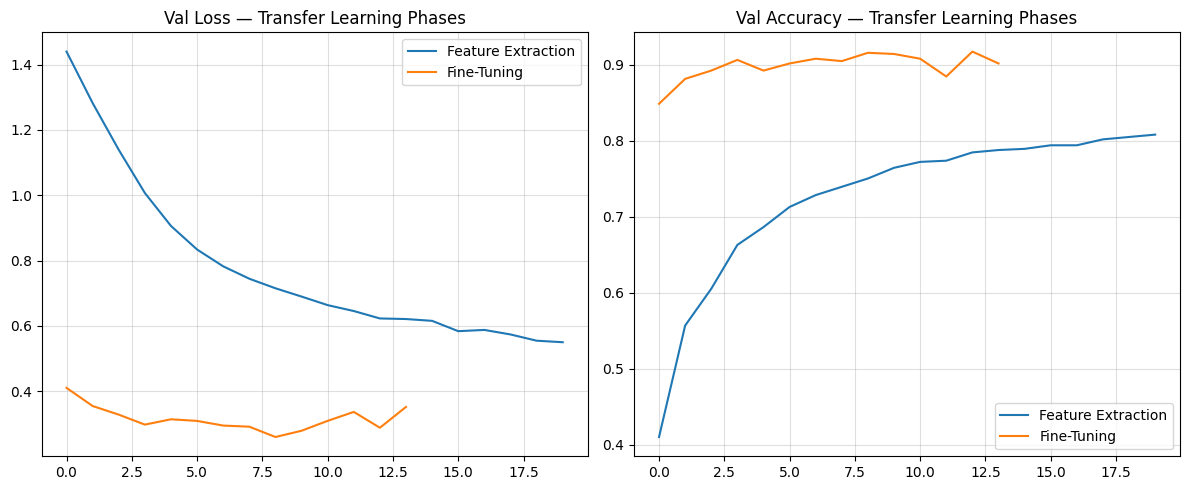

In [ ]:
# Transfer learning curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_tl.history['val_loss'], label='Feature Extraction')
plt.plot(history_ft.history['val_loss'], label='Fine-Tuning')
plt.title('Val Loss — Transfer Learning Phases'); plt.legend(); plt.grid(alpha=0.4)
plt.subplot(1, 2, 2)
plt.plot(history_tl.history['val_accuracy'], label='Feature Extraction')
plt.plot(history_ft.history['val_accuracy'], label='Fine-Tuning')
plt.title('Val Accuracy — Transfer Learning Phases'); plt.legend(); plt.grid(alpha=0.4)
plt.tight_layout(); plt.show()

Classification Report — Fine-Tuned VGG16:
              precision    recall  f1-score   support

       daisy       0.87      0.91      0.89       114
   dandelion       0.91      0.94      0.92       157
        rose       0.87      0.91      0.89       117
   sunflower       0.93      0.92      0.92       109
       tulip       0.93      0.84      0.88       147

    accuracy                           0.90       644
   macro avg       0.90      0.90      0.90       644
weighted avg       0.90      0.90      0.90       644



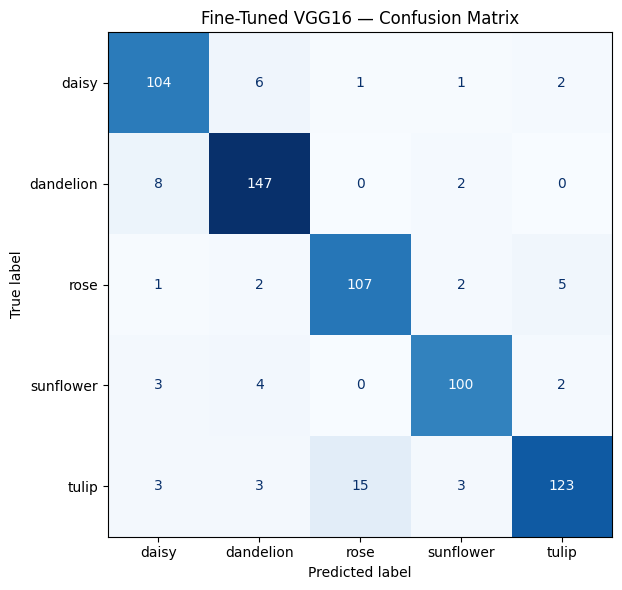

In [ ]:
# Classification report — fine-tuned VGG16
test_gen_tl.reset()
pred_probs_ft  = transfer_model_tuned.predict(test_gen_tl, verbose=0)
y_pred_ft      = np.argmax(pred_probs_ft, axis=1)
y_true_tl      = test_gen_tl.classes
class_names_tl = list(test_gen_tl.class_indices.keys())
print("Classification Report — Fine-Tuned VGG16:")
print(classification_report(y_true_tl, y_pred_ft, target_names=class_names_tl))

cm_ft = confusion_matrix(y_true_tl, y_pred_ft)
disp  = ConfusionMatrixDisplay(confusion_matrix=cm_ft, display_labels=class_names_tl)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title('Fine-Tuned VGG16 — Confusion Matrix'); plt.tight_layout(); plt.show()

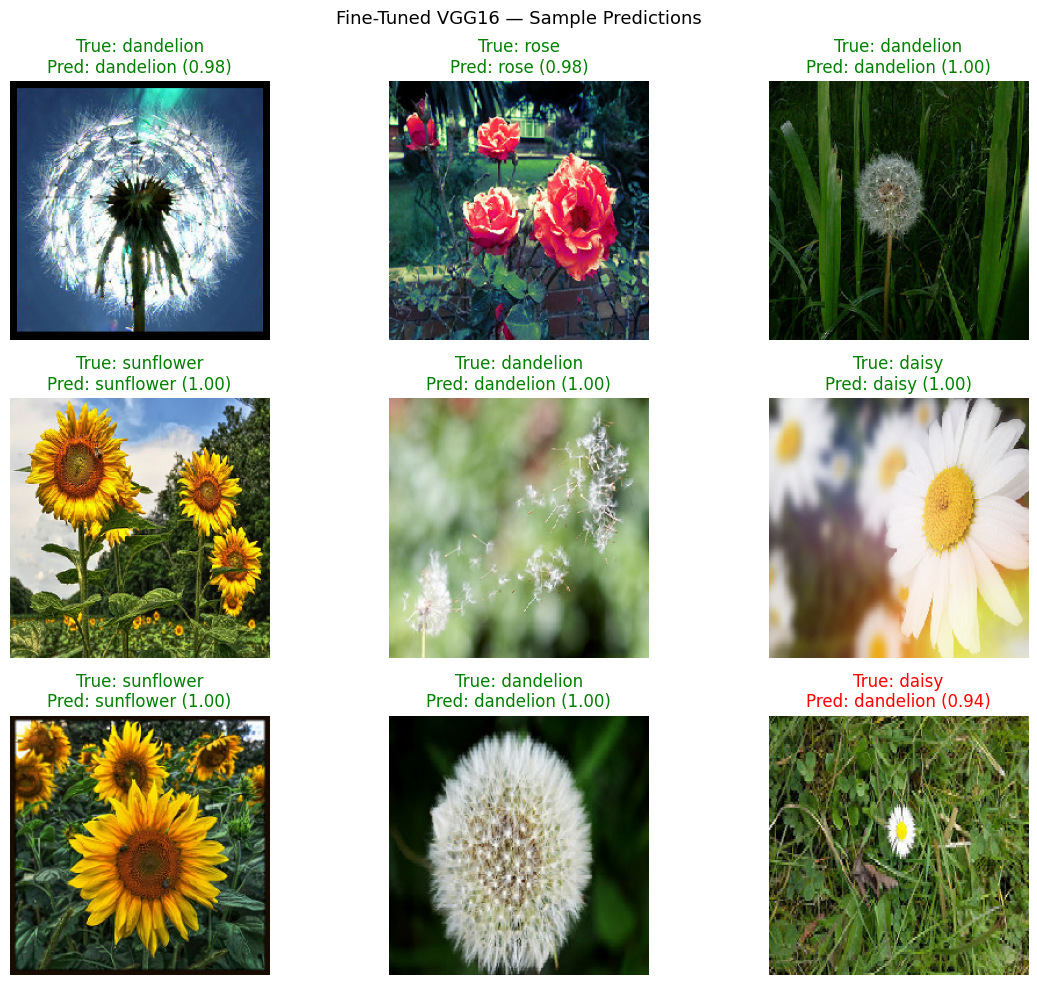

In [ ]:
# Predictions on 9 random test images — fine-tuned model
idx_to_class_tl = {v: k for k, v in test_gen_tl.class_indices.items()}
sample_paths    = random.sample(sample_data, 9)
plt.figure(figsize=(12, 10))
for i, (img_path, true_label) in enumerate(sample_paths):
    img  = load_img(img_path, target_size=IMG_SIZE_TL)
    x    = img_to_array(img) / 255.0
    x    = np.expand_dims(x, axis=0)
    prob = transfer_model_tuned.predict(x, verbose=0)[0]
    pred = idx_to_class_tl[np.argmax(prob)]
    ax   = plt.subplot(3, 3, i + 1); plt.imshow(img); plt.axis('off')
    color = 'green' if pred == true_label else 'red'
    ax.set_title(f"True: {true_label}\nPred: {pred} ({prob.max():.2f})", color=color)
plt.suptitle('Fine-Tuned VGG16 — Sample Predictions', fontsize=13)
plt.tight_layout(); plt.show()

### Final Model Comparison — All Architectures

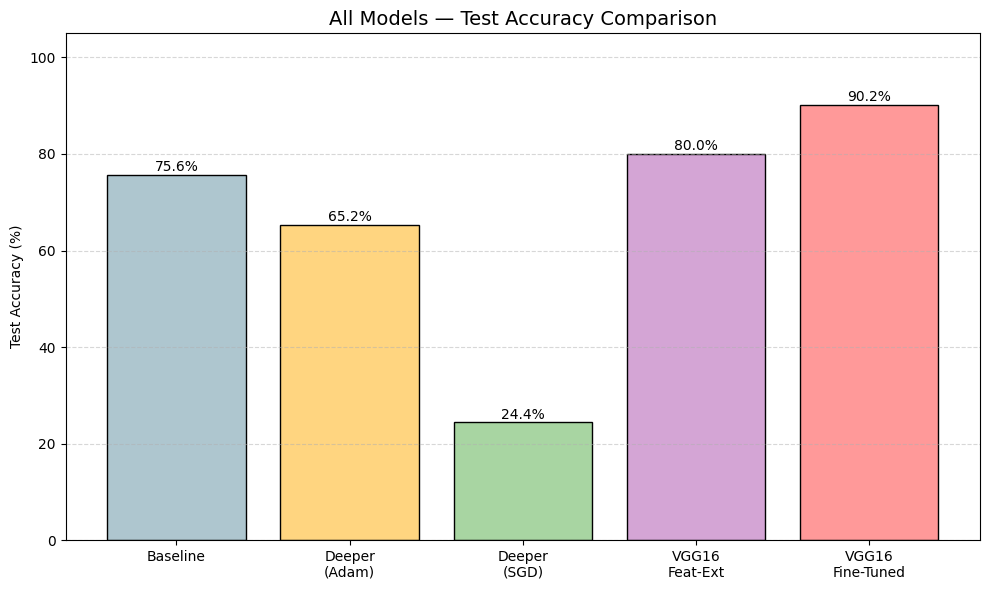


Conclusion:
Transfer learning (fine-tuned VGG16) significantly outperforms all scratch-trained models,
demonstrating the value of pre-trained ImageNet features for flower image classification.


In [ ]:
model_names = ['Baseline', 'Deeper\n(Adam)', 'Deeper\n(SGD)', 'VGG16\nFeat-Ext', 'VGG16\nFine-Tuned']
accs        = [acc_b*100, acc_d*100, acc_s*100, acc_tl*100, acc_ft*100]
palette     = ['#AEC6CF', '#FFD580', '#A8D5A2', '#D4A5D5', '#FF9999']

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accs, color=palette, edgecolor='black')
plt.ylabel('Test Accuracy (%)'); plt.ylim(0, 105)
plt.title('All Models — Test Accuracy Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.8,
             f"{b.get_height():.1f}%", ha='center', fontsize=10)
plt.tight_layout(); plt.show()

print("\nConclusion:")
print("Transfer learning (fine-tuned VGG16) significantly outperforms all scratch-trained models,")
print("demonstrating the value of pre-trained ImageNet features for flower image classification.")